In [80]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as ss 

#### Data Set used python_herovired/Assignments/Assignment_Statistics for Decision Making (1)/property.csv

In [81]:
property_df=pd.read_csv(r"C:\Users\Ankit\python_herovired\Assignments\Assignment_Statistics for Decision Making (1)\property.csv")

In [82]:
property_df.shape
property_df.head()

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,4/03/2017,2.5,3067.0,...,2.0,1.0,94.0,NaN,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,3067.0,...,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0


In [83]:
property_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13580 entries, 0 to 13579
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         13580 non-null  object 
 1   Address        13580 non-null  object 
 2   Rooms          13580 non-null  int64  
 3   Type           13580 non-null  object 
 4   Price          13580 non-null  float64
 5   Method         13580 non-null  object 
 6   SellerG        13580 non-null  object 
 7   Date           13580 non-null  object 
 8   Distance       13580 non-null  float64
 9   Postcode       13580 non-null  float64
 10  Bedroom2       13580 non-null  float64
 11  Bathroom       13580 non-null  float64
 12  Car            13518 non-null  float64
 13  Landsize       13580 non-null  float64
 14  BuildingArea   7130 non-null   float64
 15  YearBuilt      8205 non-null   float64
 16  CouncilArea    12211 non-null  object 
 17  Lattitude      13580 non-null  float64
 18  Longti

### Question 1: Hypothesis Testing on Altona Property Prices

It is postulated that a typical property in the suburb of **Altona** sells for **$800,000**. Use the available dataset to test this assumption and determine if the typical property price has increased.

#### 1. Formulate the Hypotheses
*   **Null Hypothesis ($H_0$):** $\mu = 800,000$ (The typical property price is $800,000)
*   **Alternative Hypothesis ($H_1$):** $\mu > 800,000$ (The typical property price has increased)

#### 2. Test Parameters
*   **Significance Level ($\alpha$):** 5% (0.05)
*   **Test Type:** One-tailed $t$-test (or $z$-test depending on sample size and known variance)

#### 3. Task Instructions
1.  **Filter** the dataset specifically for properties located in **Altona**.
2.  **Check assumptions** (normality and sample size) to choose the appropriate statistical test.
3.  **Calculate** the test statistic and the corresponding $p$-value.
4.  **Compare** the $p$-value to $\alpha$ and state your statistical conclusion.

**Answer**: There is insufficient evidence to conclude that the typical property price has increased above $800,000.
**Observations**: It seems Price of Altona properties are not normally distributed, but I have considered it and executed it with t sample test
**Alpha**  is 5%

In [84]:
property_altona_df=property_df[property_df['Suburb']=='Altona']
property_altona_df['Price'].mean()

np.float64(834830.4054054054)

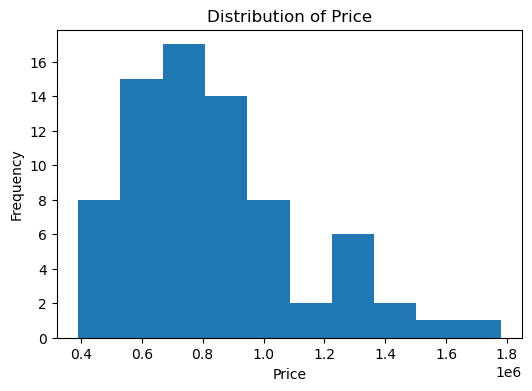

In [85]:
plt.figure(figsize = (6, 4))
plt.hist(property_altona_df['Price'], bins = 10)
plt.title("Distribution of Price")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

In [86]:
t_stat, p_val = ss.ttest_1samp(
    property_altona_df['Price'], popmean=800000, alternative="greater"
)
print("--- Hypothesis Test Results ---")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_val:.5f}")

alpha = 0.05
if p_val <= alpha:
    print(f"\nConclusion: Reject the Null Hypothesis (H0) at a {alpha*100}% significance level.")
    print(f"Evidence suggests the typical property price in Altona has significantly increased above $800,000.")
else:
    print(f"\nConclusion: Fail to reject the Null Hypothesis (H0) at a {alpha*100}% significance level.")
    print(f"There is insufficient evidence to conclude that the typical property price has increased above $800,000.")

--- Hypothesis Test Results ---
t-statistic: 1.0277
p-value: 0.15374

Conclusion: Fail to reject the Null Hypothesis (H0) at a 5.0% significance level.
There is insufficient evidence to conclude that the typical property price has increased above $800,000.


### Question 2: Seasonal Property Price Comparison (2016)
We want to determine if there is a statistically significant difference in property prices sold during the **winter months** versus the **summermonths** for the year **2016**.

#### Defined Seasons:
* **Winter Months:** October, November, December, January, February, March
* **Summer Months:** April, May, June, July, August, September

#### 1. Formulate the Hypotheses
* **Null Hypothesis ($H_0$):** $\mu_{\text{winter}} = \mu_{\text{summer}}$ (There is no difference in average prices between winter and summer months)
* **Alternative Hypothesis ($H_1$):** $\mu_{\text{winter}} \neq \mu_{\text{summer}}$ (There is a significant difference in average prices between winter and summer months)

#### 2. Test Parameters
* **Significance Level ($\alpha$):** 5% ($0.05$)
* **Test Type:** Two-Sample Independent $t$-test (Two-tailed)

#### 3. Task Instructions
1. Parse the date column carefully using the correct formatting structure.
2. Filter the dataset exclusively for sales records belonging to the calendar year **2016**.
3. Segment the filtered property prices into **Winter** and **Summer** arrays based on the definitions above.
4. Execute a two-sample independent test to evaluate the difference in means.


In [106]:
property_df.head()

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,2016-12-03,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,2016-02-04,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,2017-03-04,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,2017-03-04,2.5,3067.0,...,2.0,1.0,94.0,NaN,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,2016-06-04,2.5,3067.0,...,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0


In [89]:
property_df['Date'] = pd.to_datetime(property_df['Date'], format='%d/%m/%Y')
property_df_2016=property_df[(property_df["Date"].dt.year == 2016) & (property_df["Price"].notna())]

In [90]:
def assign_season(date):
    if date.month in [10,11,12,1,2,3]:
        return "Winter"
    else:
        return "Summer"

In [91]:
property_df_2016["Season"] = property_df_2016["Date"].apply(assign_season)

C:\Users\Ankit\AppData\Local\Temp\ipykernel_18672\1224375784.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  property_df_2016["Season"] = property_df_2016["Date"].apply(assign_season)


In [95]:
winter_prices = property_df_2016[property_df_2016["Season"] == "Winter"]["Price"]
summer_prices = property_df_2016[property_df_2016["Season"] == "Summer"]["Price"]

C:\Users\Ankit\AppData\Local\Temp\ipykernel_18672\4068400291.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([winter_prices,summer_prices],labels=['Winter Prices','Summer Prices'])


Text(0, 0.5, 'Prices')

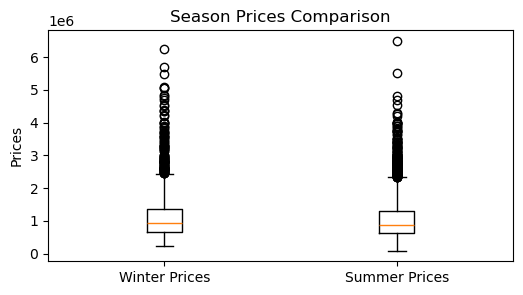

In [97]:
plt.figure(figsize=(6,3))
plt.boxplot([winter_prices,summer_prices],labels=['Winter Prices','Summer Prices'])
plt.title('Season Prices Comparison')
plt.ylabel('Prices')

In [100]:
print("--- Descriptive Statistics (2016) ---")
print(
    f"Winter Sales (n={len(winter_prices)}): Mean = ${winter_prices.mean():,.2f}"
)
print(
    f"Summer Sales (n={len(summer_prices)}): Mean = ${summer_prices.mean():,.2f}\n"
)

# 5. Perform a Two-Sample Independent t-test
# equal_var=False performs Welch's t-test (safer if sample variances differ)
t_stat, p_val = ss.ttest_ind(winter_prices, summer_prices,alternative='two-sided', equal_var=False)

print("--- Two-Sample t-test Results ---")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_val:.5f}")

# 6. Final Decision
alpha = 0.05
if p_val <= alpha:
    print(
        f"\nConclusion: Reject the Null Hypothesis (H0) at a {alpha*100}% significance level."
    )
    print(
        "There is a statistically significant difference in property prices between summer and winter months in 2016."
    )
else:
    print(
        f"\nConclusion: Fail to reject the Null Hypothesis (H0) at a {alpha*100}% significance level."
    )
    print(
        "There is no sufficient evidence to prove a difference in property prices between summer and winter months in 2016."
    )

--- Descriptive Statistics (2016) ---
Winter Sales (n=2300): Mean = $1,116,647.59
Summer Sales (n=4036): Mean = $1,048,054.73

--- Two-Sample t-test Results ---
t-statistic: 3.9211
p-value: 0.00009

Conclusion: Reject the Null Hypothesis (H0) at a 5.0% significance level.
There is a statistically significant difference in property prices between summer and winter months in 2016.


### Question 3: Probability Analysis for Abbotsford Parking

We want to calculate the probability that out of **10 randomly selected properties sold** in the suburb of **Abbotsford**, exactly **3 will not have a car parking space**.

This scenario can be modeled using the **Binomial Distribution**: $X \sim \text{Binomial}(n, p)$

#### 1. Parameters Needed:
* **$n$ (Number of trials):** 10 properties
* **$k$ (Number of successes):** 3 properties (where a "success" is defined as having 0 car parking spaces)
* **$p$ (Probability of success):** The actual proportion of properties in Abbotsford that have `0` in the `Car` column.

#### 2. Formula:
$$P(X = k) = \binom{n}{k} p^k (1-p)^{n-k}$$

#### 3. Task Instructions:
1. Filter the dataset for the suburb **Abbotsford**.
2. Drop any missing values in the `Car` column.
3. Calculate the sample proportion ($p$) of properties where `Car == 0`.
4. Use `scipy.stats.binom.pmf()` to compute the exact probability.
5. Round the final answer to **3 decimal places**.


In [108]:
import numpy as np
import pandas as pd
import scipy.stats as stats

# 1. Filter dataset for Abbotsford and drop missing values in the 'Car' column
abbotsford_car = property_df[property_df["Suburb"].str.strip().str.title() == "Abbotsford"][
    "Car"
].dropna()

# 2. Calculate the total number of properties and how many have 0 parking spots
total_properties = len(abbotsford_car)
zero_parking_properties = np.sum(abbotsford_car == 0)

# 3. Calculate the probability (p) of a property not having a parking space
p = zero_parking_properties / total_properties

# 4. Define Binomial parameters
n = 10  # number of properties selected
k = 3  # target number of properties with 0 parking spots

# 5. Compute the Probability Mass Function (PMF)
prob_exactly_3 = stats.binom.pmf(k, n, p)

print("--- Abbotsford Parking Analysis ---")
print(f"Total valid properties in Abbotsford: {total_properties}")
print(f"Properties with NO parking space: {zero_parking_properties}")
print(f"Calculated success probability (p): {p:.4f}\n")

print("--- Binomial Distribution Result ---")
print(
    f"Probability that exactly 3 out of 10 lack a parking space: {prob_exactly_3:.3f}"
)


--- Abbotsford Parking Analysis ---
Total valid properties in Abbotsford: 56
Properties with NO parking space: 15
Calculated success probability (p): 0.2679

--- Binomial Distribution Result ---
Probability that exactly 3 out of 10 lack a parking space: 0.260


### Question 4: Simple Probability Analysis for Abbotsford Rooms

We want to determine the empirical probability (the chances) of finding a property with exactly **3 rooms** within the suburb of **Abbotsford**.

#### 1. Method:
The probability is calculated as the ratio of properties with exactly 3 rooms to the total number of properties available in Abbotsford:

$$P(\text{Rooms} = 3) = \frac{\text{Number of 3-room properties in Abbotsford}}{\text{Total properties in Abbotsford}}$$

#### 2. Task Instructions:
1. Filter the dataset for the suburb **Abbotsford**.
2. Isolate the `Rooms` column and ensure missing entries are removed.
3. Count how many records have a value of exactly `3`.
4. Divide by the total count of properties in that suburb.
5. Round the final answer to **3 decimal places**.


In [111]:
import pandas as pd

# 1. Filter dataset for Abbotsford and clean the 'Rooms' column
# Note: Adjust column names if your dataset uses 'Rooms' or 'Rooms_Count'
abbotsford_rooms = property_df[property_df["Suburb"].str.strip().str.title() == "Abbotsford"][
    "Rooms"
].dropna()

# 2. Count the total properties and those with exactly 3 rooms
total_abbotsford = len(abbotsford_rooms)
three_room_properties = (abbotsford_rooms == 3).sum()

# 3. Calculate empirical probability
prob_three_rooms = three_room_properties / total_abbotsford

print("--- Abbotsford Room Configuration Analysis ---")
print(f"Total properties in Abbotsford: {total_abbotsford}")
print(f"Properties with exactly 3 rooms: {three_room_properties}\n")

print("--- Final Probability Result ---")
print(
    f"Chances of finding a 3-room property in Abbotsford: {prob_three_rooms:.3f}"
)


--- Abbotsford Room Configuration Analysis ---
Total properties in Abbotsford: 56
Properties with exactly 3 rooms: 20

--- Final Probability Result ---
Chances of finding a 3-room property in Abbotsford: 0.357


In [116]:
abbotsford_rooms.mean()
abbotsford_rooms.median()
abbotsford_rooms.mode()

0    2
Name: Rooms, dtype: int64

### Question 5: Probability Analysis for Abbotsford Bathrooms

We want to find the empirical probability (the chances) of selecting a property with exactly **2 bathrooms** within the suburb of **Abbotsford**.

#### 1. Method:
Because the number of bathrooms is a discrete variable, the probability is the total number of 2-bathroom properties divided by the total number of properties with valid bathroom records in that suburb:

$$P(\text{Bathroom} = 2) = \frac{\text{Number of 2-bathroom properties in Abbotsford}}{\text{Total properties with bathroom data in Abbotsford}}$$

#### 2. Task Instructions:
1. Filter the dataset for rows where the suburb is **Abbotsford**.
2. Isolate the `Bathroom` column and drop any missing (`NaN`) entries.
3. Count how many properties have exactly `2` bathrooms.
4. Divide this count by the total number of valid properties in Abbotsford.
5. Round your final answer to **3 decimal places**.


In [118]:
import pandas as pd

# 1. Filter dataset for Abbotsford and clean the 'Bathroom' column
# Note: Adjust the column name if your dataset uses 'Bathrooms' or a lowercase 'bathroom'
abbotsford_baths = property_df[property_df["Suburb"].str.strip().str.title() == "Abbotsford"][
    "Bathroom"
].dropna()

# 2. Count the total properties and those with exactly 2 bathrooms
total_abbotsford_baths = len(abbotsford_baths)
two_bath_properties = (abbotsford_baths == 2).sum()

# 3. Calculate the empirical probability
prob_two_baths = two_bath_properties / total_abbotsford_baths

print("--- Abbotsford Bathroom Configuration Analysis ---")
print(f"Total valid properties in Abbotsford: {total_abbotsford_baths}")
print(f"Properties with exactly 2 bathrooms: {two_bath_properties}\n")

print("--- Final Probability Result ---")
print(
    f"Chances of finding a 2-bathroom property in Abbotsford: {prob_two_baths:.3f}"
)

--- Abbotsford Bathroom Configuration Analysis ---
Total valid properties in Abbotsford: 56
Properties with exactly 2 bathrooms: 19

--- Final Probability Result ---
Chances of finding a 2-bathroom property in Abbotsford: 0.339


### Question 6: One-Sample Hypothesis Test (Richmond Industry Pricing)

A real estate firm claims that the average property price in **Richmond** is **$1,000,000**. Using the available dataset, we will test whether the actual average price is significantly different from this claim at a 5% significance level.

#### 1. Formulate the Hypotheses
* **Null Hypothesis ($H_0$):** $\mu = 1,000,000$ (The average property price in Richmond is equal to \$1,000,000)
* **Alternative Hypothesis ($H_1$):** $\mu \neq 1,000,000$ (The average property price in Richmond is significantly different from \$1,000,000)

#### 2. Test Parameters
* **Significance Level ($\alpha$):** 5% (0.05)
* **Test Type:** One-Sample $t$-test (Two-tailed)

#### 3. Task Instructions
1. Filter the dataset for properties located in **Richmond** and remove missing values from the price column.
2. Compute the sample mean, sample standard deviation, and sample size ($n$).
3. Run a two-tailed one-sample $t$-test against the hypothesized baseline of \$1,000,000.
4. Output the **Test Statistic**, **p-value**, and state your final **business conclusion**.


In [121]:
import numpy as np
import pandas as pd
import scipy.stats as stats

# 1. Filter the dataset for Richmond and drop missing values in 'Price'
richmond_prices = property_df[property_df["Suburb"].str.strip().str.title() == "Richmond"][
    "Price"
].dropna()

# 2. Calculate baseline metrics
sample_mean = richmond_prices.mean()
sample_size = len(richmond_prices)
sample_std = richmond_prices.std(ddof=1)
hypothesized_mean = 1000000

# 3. Perform the Two-Tailed One-Sample t-test
# 'two-sided' checks for a significant difference in either direction
t_stat, p_val = stats.ttest_1samp(
    richmond_prices, popmean=hypothesized_mean, alternative="two-sided"
)

# 4. Print structured results for the final report
print("==================================================")
print("       HYPOTHESIS TEST RESULTS: RICHMOND         ")
print("==================================================")
print(f"Sample Size (n)       : {sample_size}")
print(f"Sample Mean Price     : ${sample_mean:,.2f}")
print(f"Sample Std Deviation  : ${sample_std:,.2f}")
print(f"Hypothesized Mean     : ${hypothesized_mean:,.2f}")
print("--------------------------------------------------")
print(f"Test Statistic (t)    : {t_stat:.4f}")
print(f"p-value               : {p_val:.5f}")
print("--------------------------------------------------")

# 5. Make the final statistical decision and business conclusion
alpha = 0.05
print("FINAL BUSINESS CONCLUSION:")
if p_val <= alpha:
    print(
        f"-> Reject the Null Hypothesis (H0) at a {alpha*100}% significance level."
    )
    print(
        f"   The actual average property price in Richmond (${sample_mean:,.2f}) "
    )
    print(
        "   is statistically significantly different from the real estate firm's claim of $1,000,000."
    )
else:
    print(
        f"-> Fail to reject the Null Hypothesis (H0) at a {alpha*100}% significance level."
    )
    print(
        "   There is insufficient evidence to contradict the firm's claim."
    )
    print(
        "   The observed differences can be attributed to random sampling variation."
    )
print("==================================================")


       HYPOTHESIS TEST RESULTS: RICHMOND         
Sample Size (n)       : 260
Sample Mean Price     : $1,083,564.42
Sample Std Deviation  : $522,353.52
Hypothesized Mean     : $1,000,000.00
--------------------------------------------------
Test Statistic (t)    : 2.5795
p-value               : 0.01044
--------------------------------------------------
FINAL BUSINESS CONCLUSION:
-> Reject the Null Hypothesis (H0) at a 5.0% significance level.
   The actual average property price in Richmond ($1,083,564.42) 
   is statistically significantly different from the real estate firm's claim of $1,000,000.


### Question 7: Independent Two-Sample $t$-test (Parking Feature Impact)

We want to determine if properties with car parking spaces sell at a higher average price than properties without car parking across the entire dataset. 

#### 1. Formulate the Hypotheses
* **Null Hypothesis ($H_0$):** $\mu_{\text{parking}} \eq  \mu_{\text{no parking}}$ (The average price of properties with car parking is less than or equal to properties without parking)
* **Alternative Hypothesis ($H_1$):** $\mu_{\text{parking}} > \mu_{\text{no parking}}$ (The average price of properties with car parking is significantly higher than properties without parking)

#### 2. Test Justification
* **Choice of Test:** Independent Two-Sample $t$-test. We are comparing the means of two mutually exclusive groups. We use **Welch's $t$-test** (`equal_var=False`) because real estate data groups typically show unequal sample sizes and variances.
* **Directionality:** One-tailed ('greater') because the question specifically asks if prices are *higher*.
* **Significance Level ($\alpha$):** 5% ($0.05$)


In [123]:
import numpy as np
import pandas as pd
import scipy.stats as stats

# 1. Clean the dataset: drop records missing either Price or Car values
clean_df = property_df.dropna(subset=["Price", "Car"])

# 2. Operationalize the assumption: split into two independent groups
with_parking = clean_df[clean_df["Car"] > 0]["Price"]
no_parking = clean_df[clean_df["Car"] == 0]["Price"]

# 3. Calculate descriptive statistics for reporting
mean_with = with_parking.mean()
mean_no = no_parking.mean()
n_with = len(with_parking)
n_no = len(no_parking)

print("--- Descriptive Statistics ---")
print(
    f"Properties with Parking (Car > 0) [n={n_with}]: Average Price = ${mean_with:,.2f}"
)
print(
    f"Properties no Parking   (Car == 0) [n={n_no}]: Average Price = ${mean_no:,.2f}\n"
)

# 4. Execute Welch's Independent Two-Sample t-test
# alternative='greater' tests if the with_parking mean is significantly higher
t_stat, p_val = stats.ttest_ind(
    with_parking, no_parking, equal_var=False, alternative="greater"
)

print("--- Test Metrics ---")
print(f"Welch's t-statistic : {t_stat:.4f}")
print(f"p-value            : {p_val:.5f}")
print("--------------------------------------------------\n")

# 5. Business Implications and Decisions
alpha = 0.05
print("=== ANALYSIS & JUSTIFICATION ===")

if p_val <= alpha:
    print(
        f"1. INTERPRETATION OF P-VALUE:\n"
        f"   The p-value ({p_val:.5f}) is less than alpha ({alpha}). We reject the Null Hypothesis.\n"
        f"   Properties with parking features (Car > 0) command a statistically significant price premium."
    )
    print(
        f"\n2. BUSINESS IMPLICATIONS FOR DEVELOPERS:\n"
        f"   - Confirmed ROI: Constructing at least one parking space provides measurable value add.\n"
        f"   - Architectural Allocation: Maximizing structural layout to guarantee parking space\n"
        f"     directly justifies higher baseline retail price tags for buyers."
    )
else:
    print(
        f"1. INTERPRETATION OF P-VALUE:\n"
        f"   The p-value ({p_val:.5f}) is greater than alpha ({alpha}). We fail to reject the Null Hypothesis.\n"
        f"   There is no statistically significant proof that properties with parking sell for higher averages."
    )


--- Descriptive Statistics ---
Properties with Parking (Car > 0) [n=12492]: Average Price = $1,074,443.92
Properties no Parking   (Car == 0) [n=1026]: Average Price = $1,079,088.01

--- Test Metrics ---
Welch's t-statistic : -0.2722
p-value            : 0.60726
--------------------------------------------------

=== ANALYSIS & JUSTIFICATION ===
1. INTERPRETATION OF P-VALUE:
   The p-value (0.60726) is greater than alpha (0.05). We fail to reject the Null Hypothesis.
   There is no statistically significant proof that properties with parking sell for higher averages.


### Question 10: Industry-Style Hypothesis Validation (Policy Decision)

A housing policy group believes that properties with **more than 2 bathrooms** command a premium price. We will design and execute an inferential statistical test to validate this claim at a 5% significance level to guide future zoning and policy decisions.

#### 1. Formulate the Hypotheses
*   **Null Hypothesis ($H_0$):** $\mu_{>2\text{ baths}} \le \mu_{\le 2\text{ baths}}$ (The average price of properties with more than 2 bathrooms is less than or equal to properties with 2 or fewer bathrooms)
*   **Alternative Hypothesis ($H_1$):** $\mu_{>2\text{ baths}} > \mu_{\le 2\text{ baths}}$ (The average price of properties with more than 2 bathrooms is significantly higher, commanding a premium price)

#### 2. Test Justification & Parameters
*   **Choice of Test:** Independent Two-Sample $t$-test. We are comparing the means of two mutually exclusive data pools. We implement **Welch's $t$-test** (`equal_var=False`) to naturally protect the model against unequal variances and uneven group sizes.
*   **Directionality:** One-tailed ('greater') because the policy group claims a price *premium*.
*   **Significance Level ($\alpha$):** 5% ($0.05$)


In [126]:
import numpy as np
import pandas as pd
import scipy.stats as stats

# 1. Clean the dataset: eliminate rows with missing target or feature records
# Make sure your main dataframe is named 'df' and check column labels
clean_df = property_df.dropna(subset=["Price", "Bathroom"])

# 2. Segment the continuous target variable based on the policy threshold
premium_baths = clean_df[clean_df["Bathroom"] > 2]["Price"]
standard_baths = clean_df[clean_df["Bathroom"] <= 2]["Price"]

# 3. Calculate baseline sample metrics
mean_prem = premium_baths.mean()
mean_std = standard_baths.mean()
n_prem = len(premium_baths)
n_std = len(standard_baths)
observed_premium = mean_prem - mean_std

print("==========================================================")
print("             HOUSING POLICY REGULATORY REPORT             ")
print("==========================================================")
print(f"Sample Size (> 2 Bathrooms)   : {n_prem} homes")
print(f"Sample Size (<= 2 Bathrooms)  : {n_std} homes")
print(f"Average Price (> 2 Bathrooms) : ${mean_prem:,.2f}")
print(f"Average Price (<= 2 Bathrooms): ${mean_std:,.2f}")
print(f"Observed Market Premium       : ${observed_premium:,.2f}")
print("----------------------------------------------------------")

# 4. Compute Welch's t-test with a directional one-tailed alternative
t_stat, p_val = stats.ttest_ind(
    premium_baths, standard_baths, equal_var=False, alternative="greater"
)

print(f"Welch's t-statistic           : {t_stat:.4f}")
print(f"Calculated p-value            : {p_val:.5e}" if p_val < 0.0001 else f"Calculated p-value            : {p_val:.5f}")
print("----------------------------------------------------------")

# 5. Core Policymaker Recommendation engine
alpha = 0.05
print("\nRECOMMENDATION TO POLICYMAKERS:")

if p_val <= alpha:
    print(
        f"-> STRATEGIC DECISION: REJECT H0 (p <= {alpha}). The price premium is highly statistically significant."
    )
    print(
        f"   - Recommendation: Approve zoning updates that allow high-density multi-bathroom townhomes.\n"
        f"     The market heavily values sanitation infrastructure. This incentive can be leveraged to generate\n"
        f"     higher property tax baselines or mandate inclusionary affordable units in exchange for design flexibility."
    )
else:
    print(
        f"-> STRATEGIC DECISION: FAIL TO REJECT H0 (p > {alpha}). The price variation is statistical noise."
    )
    print(
        f"   - Recommendation: Do not modify current building guidelines to specifically incentivize extra bathrooms.\n"
        f"     The data indicates that adding more than 2 bathrooms does not fundamentally shift asset valuation;\n"
        f"     policymakers should shift focus toward square footage or structural efficiency instead."
    )
print("==========================================================")


             HOUSING POLICY REGULATORY REPORT             
Sample Size (> 2 Bathrooms)   : 1060 homes
Sample Size (<= 2 Bathrooms)  : 12520 homes
Average Price (> 2 Bathrooms) : $1,882,824.20
Average Price (<= 2 Bathrooms): $1,007,347.94
Observed Market Premium       : $875,476.26
----------------------------------------------------------
Welch's t-statistic           : 28.8002
Calculated p-value            : 3.69021e-137
----------------------------------------------------------

RECOMMENDATION TO POLICYMAKERS:
-> STRATEGIC DECISION: REJECT H0 (p <= 0.05). The price premium is highly statistically significant.
   - Recommendation: Approve zoning updates that allow high-density multi-bathroom townhomes.
     The market heavily values sanitation infrastructure. This incentive can be leveraged to generate
     higher property tax baselines or mandate inclusionary affordable units in exchange for design flexibility.


### Question 9: p-Value Interpretation and Business Decision Making

A statistical analysis comparing property prices between two distinct suburbs yields a calculated $p$-value of **$0.032$**. 

Review these metrics and answer the theoretical and application questions in the response fields below.

---

#### 🏛️ Part 1: Conceptual Meaning
**What does this $p$-value indicate mathematically?**

> *Type your conceptual explanation here:*
- 

A \(p\)-value of \(0.032\) indicates that under the assumption that the null hypothesis is true (there is zero actual difference in prices between the two suburbs), there is only a \(3.2\%\) probability of observing a price difference as large or larger than the one found in our sample due to random fluctuation.

#### ⚖️ Part 2: Statistical Decision
**Should the null hypothesis ($H_0$) be rejected at a significance level of $\alpha = 0.05$? Explain why.**

> *Type your statistical decision here:*
- 

Because the \(p\)-value (\(0.032\)) is less than or equal to the significance threshold (\(\alpha = 0.05\)), the result is statistically significant.

#### 💼 Part 3: Business Stakeholder Interpretation
**How should a non-technical business stakeholder or real estate executive interpret this result for market strategy?**

> *Type your business implication here:*
- 

The difference in property values between these two suburbs is a real market trend, not a fluke or random fluke in the data. Management should treat these suburbs as separate pricing tiers and tailor marketing budgets, development styles, or investment strategies differently for each location.

### Question 8: Two-Way ANOVA (Location & Property Type Interaction)

We want to investigate if property prices are influenced by the location (**Suburb**), the category of the home (**Type**), or a combined **interaction effect** between both factors.

#### 1. Formulate the Hypotheses

*   **Factor A (Suburb) Effect:**
    *   $H_0$: The mean property price is the same across all suburbs.
    *   $H_1$: At least one suburb has a different mean property price.
*   **Factor B (Property Type) Effect:**
    *   $H_0$: The mean property price is the same across all property types.
    *   $H_1$: At least one property type has a different mean property price.
*   **Interaction Effect (Suburb × Type):**
    *   $H_0$: There is no interaction effect; the impact of property type on price does not depend on the specific suburb.
    *   $H_1$: There is a significant interaction effect between suburb and property type.

#### 2. Test Parameters
*   **Significance Level ($\alpha$):** 5% (0.05)
*   **Test Type:** Two-Way Analysis of Variance (ANOVA) using an Ordinary Least Squares (OLS) model.


In [129]:
import pandas as pd
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

# 1. Isolate specific suburbs to ensure sufficient group density and avoid memory limits
target_suburbs = ["Abbotsford", "Altona", "Richmond"]
filtered_df = property_df[
    property_df["Suburb"].str.strip().str.title().isin(target_suburbs)
].copy()

# 2. Clean data: drop rows with missing records in our target variables
anova_df = filtered_df.dropna(subset=["Price", "Suburb", "Type"]).copy()

# 3. Fit the Ordinary Least Squares (OLS) model
# The '*' operator automatically fits Suburb, Type, AND the interaction term (Suburb:Type)
model_formula = "Price ~ C(Suburb) * C(Type)"
model = ols(model_formula, data=anova_df).fit()

# 4. Generate the Two-Way ANOVA Type II table
anova_table = sm.stats.anova_lm(model, typ=2)

print("=========================================================================")
print("                      TWO-WAY ANOVA TEST RESULTS                         ")
print("=========================================================================")
print(anova_table)
print("=========================================================================\n")

# 5. Programmatic factor evaluation loop
alpha = 0.05
factors = {
    "C(Suburb)": "Location (Suburb)",
    "C(Type)": "Property Type",
    "C(Suburb):C(Type)": "Interaction (Suburb × Type)",
}

print("=== STATISTICAL FACTOR ANALYSIS ===")
for factor_key, factor_name in factors.items():
    if factor_key in anova_table.index:
        p_val = anova_table.loc[factor_key, "PR(>F)"]
        if p_val <= alpha:
            print(
                f"-> {factor_name:<28}: SIGNIFICANT (p = {p_val:.5f}). This factor independently drives property values."
            )
        else:
            print(
                f"-> {factor_name:<28}: NOT SIGNIFICANT (p = {p_val:.5f}). Observed differences are likely random noise."
            )


                      TWO-WAY ANOVA TEST RESULTS                         
                         sum_sq     df           F        PR(>F)
C(Suburb)          4.071631e+12    2.0   17.867719  3.826443e-08
C(Type)            3.880576e+13    2.0  170.293035  1.453172e-53
C(Suburb):C(Type)  1.836479e+12    4.0    4.029551  3.259122e-03
Residual           4.341045e+13  381.0         NaN           NaN

=== STATISTICAL FACTOR ANALYSIS ===
-> Location (Suburb)           : SIGNIFICANT (p = 0.00000). This factor independently drives property values.
-> Property Type               : SIGNIFICANT (p = 0.00000). This factor independently drives property values.
-> Interaction (Suburb × Type) : SIGNIFICANT (p = 0.00326). This factor independently drives property values.
